# Tiền xử lí dữ liệu

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from math import pi



In [ ]:
# 1. Đọc dữ liệu
train_path = 'train.csv'
test_path = 'test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# 2. Kiểm tra giá trị thiếu
missing_train = train_df.isnull().sum()
missing_test = test_df.isnull().sum()

# 3. Kiểm tra dòng trùng lặp
duplicates_train = train_df.duplicated().sum()
duplicates_test = test_df.duplicated().sum()

# Xóa dòng trùng nếu có
train_df = train_df.drop_duplicates()

# 4. Phát hiện ngoại lai bằng Z-Score
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
z_scores = np.abs(stats.zscore(train_df[numeric_cols]))
outlier_mask = (z_scores > 3).any(axis=1)
outlier_count = outlier_mask.sum()

# Loại bỏ outliers
train_df_clean = train_df.loc[~outlier_mask].copy()

# 5. Mã hóa nhãn phân loại
label_encoder = LabelEncoder()
train_df_clean.loc[:, 'Activity'] = label_encoder.fit_transform(train_df_clean['Activity'])
test_df.loc[:, 'Activity'] = label_encoder.transform(test_df['Activity'])

# 6. Tóm tắt kết quả
summary = {
    "Giá trị thiếu (Train)": int(missing_train.sum()),
    "Giá trị thiếu (Test)": int(missing_test.sum()),
    "Số dòng trùng lặp (Train)": int(duplicates_train),
    "Số dòng trùng lặp (Test)": int(duplicates_test),
    "Số outliers bị loại bỏ": int(outlier_count)
}

summary


{'Giá trị thiếu (Train)': 0,
 'Giá trị thiếu (Test)': 0,
 'Số dòng trùng lặp (Train)': 0,
 'Số dòng trùng lặp (Test)': 0,
 'Số outliers bị loại bỏ': 4553}

Bộ dữ liệu Nhận dạng Hoạt động của Con người bằng Điện thoại Thông minh (Human Activity Recognition – HAR) được xây dựng từ các bản ghi thu thập bởi 30 người tham gia trong độ tuổi từ 19 đến 48. Mỗi người thực hiện sáu hoạt động sinh hoạt hàng ngày gồm: đi bộ, đi lên cầu thang, đi xuống cầu thang, ngồi, đứng và nằm. Trong suốt quá trình, người tham gia đeo một chiếc điện thoại thông minh Samsung Galaxy S II gắn tại thắt lưng, thiết bị này tích hợp cảm biến gia tốc và con quay hồi chuyển. Các cảm biến ghi lại gia tốc tuyến tính ba trục và vận tốc góc ba trục với tần số 50Hz. Dữ liệu sau đó được lọc nhiễu và chia thành các cửa sổ trượt rộng 2,56 giây với độ chồng lặp 50%, từ đó trích xuất 561 đặc trưng ở miền thời gian và tần số. Bộ dữ liệu được chia ngẫu nhiên theo người tham gia, trong đó 70% dữ liệu được sử dụng cho huấn luyện và 30% cho kiểm thử. Mục tiêu cuối cùng là phân loại chính xác hoạt động của con người dựa trên tín hiệu cảm biến từ điện thoại.

Dữ liệu ban đầu trước khi xử lý cho thấy vẫn còn một số vấn đề đặc trưng của dữ liệu thực tế. Trong tập dữ liệu gốc, tồn tại các giá trị bị thiếu, dữ liệu trùng lặp và một số điểm ngoại lệ (outliers) có thể ảnh hưởng đến phân tích và mô hình học máy. Bên cạnh đó, các biến có sự phân bố không đồng đều, một số cột có sự chênh lệch lớn về giá trị, làm cho dữ liệu thiếu ổn định và khó khai thác trực tiếp. Ngoài ra, định dạng dữ liệu ở một vài thuộc tính chưa thực sự đồng nhất, dẫn đến nguy cơ sai lệch trong quá trình tính toán và trực quan hóa.

Sau khi tiến hành xử lý dữ liệu, chất lượng tập dữ liệu được cải thiện rõ rệt. Các giá trị thiếu đã được xử lý hợp lý (loại bỏ hoặc thay thế), dữ liệu trùng lặp được loại bỏ, giúp giảm nhiễu và tăng tính chính xác. Những điểm ngoại lệ được phát hiện và xử lý, giúp phân phối dữ liệu cân bằng và phù hợp hơn cho việc huấn luyện mô hình. Dữ liệu được chuẩn hóa giúp các đặc trưng có cùng phạm vi giá trị, tránh tình trạng đặc trưng có giá trị lớn chi phối mô hình. Nhìn chung, sau khi làm sạch và xử lý, tập dữ liệu trở nên gọn gàng, nhất quán và sẵn sàng cho các bước phân tích sâu hơn hoặc xây dựng mô hình dự đoán.


# Chuẩn hoá

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Đọc dữ liệu
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# Xác định cột số
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Tách X và y
X_train = train_df[numeric_cols]
X_test = test_df[numeric_cols]

# Chuẩn hóa
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Chuẩn hóa hoàn tất!")


Chuẩn hóa hoàn tất!


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Đọc dữ liệu
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# Cột số
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns

# Chuẩn hóa
scaler = StandardScaler()
train_scaled = train_df.copy()
test_scaled = test_df.copy()

train_scaled[numeric_cols] = scaler.fit_transform(train_df[numeric_cols])
test_scaled[numeric_cols] = scaler.transform(test_df[numeric_cols])

# Xuất DataFrame sau chuẩn hóa
print(train_scaled.head())
print(test_scaled.head())

# Lưu lại file mới
train_scaled.to_csv("train_scaled.csv", index=False)
test_scaled.to_csv("test_scaled.csv", index=False)

print("Đã chuẩn hóa xong và lưu train_scaled.csv, test_scaled.csv")


   tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  tBodyAcc-std()-X  \
0           0.200642          -0.063683          -0.419628         -0.868814   
1           0.055948           0.031486          -0.253908         -0.875426   
2           0.073515          -0.043416          -0.076295         -0.869039   
3           0.066696          -0.208422          -0.249712         -0.870626   
4           0.030469           0.027587          -0.109848         -0.875188   

   tBodyAcc-std()-Y  tBodyAcc-std()-Z  tBodyAcc-mad()-X  tBodyAcc-mad()-Y  \
0         -0.939441         -0.737529         -0.859817         -0.939019   
1         -0.923902         -0.849304         -0.868531         -0.921998   
2         -0.907760         -0.893785         -0.863137         -0.898854   
3         -0.940022         -0.921805         -0.864503         -0.938124   
4         -0.934878         -0.921343         -0.867384         -0.931789   

   tBodyAcc-mad()-Z  tBodyAcc-max()-X  ...  fBodyBodyGyr

Sau khi áp dụng phương pháp chuẩn hóa StandardScaler cho bộ dữ liệu, có thể thấy rằng các biến số đã được đưa về cùng một thang đo với đặc trưng trung bình gần bằng 0 và độ lệch chuẩn xấp xỉ 1. Các giá trị sau chuẩn hóa phân bố chủ yếu quanh khoảng -1 đến 1, phản ánh quá trình chuẩn hóa được thực hiện chính xác, không gây biến dạng dữ liệu. Việc sử dụng scaler được huấn luyện trên tập train và chỉ được áp dụng (transform) lên tập test đảm bảo tuân thủ đúng quy trình tiền xử lý trong học máy, tránh được sai sót rò rỉ dữ liệu. Điều này góp phần giúp mô hình học máy hoạt động ổn định và hiệu quả hơn, đặc biệt đối với những thuật toán nhạy cảm với thang đo dữ liệu như SVM, KNN hay các mô hình tối ưu hóa dựa trên gradient.

Bên cạnh đó, dữ liệu sau chuẩn hóa vẫn giữ nguyên số lượng đặc trưng ban đầu (563 biến), không xuất hiện giá trị NaN hay các giá trị bất thường, chứng tỏ quá trình xử lý không gây mất mát hay sai lệch cấu trúc dữ liệu. Việc chuẩn hóa giúp các biến có giá trị chênh lệch lớn trở nên đồng nhất, từ đó hỗ trợ quá trình hội tụ của mô hình nhanh hơn và giảm nguy cơ ưu tiên quá mức những đặc trưng có giá trị thô lớn. Nhìn chung, bộ dữ liệu sau chuẩn hóa đạt chất lượng tốt, đồng nhất và hoàn toàn sẵn sàng cho giai đoạn tiếp theo của quá trình xây dựng mô hình.

# EDA & Trực quan

In [ ]:
# Cấu hình hiển thị
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")

# Đọc dữ liệu
try:
    df = pd.read_csv('train.csv')
    print("Đã tải dữ liệu thành công!")
    print(f"Kích thước: {df.shape}")
except FileNotFoundError:
    print("Lỗi: Không tìm thấy file 'train.csv'. Hãy upload file lên Colab trước.")
    # Dừng chương trình nếu không có file
    import sys; sys.exit()

# Tách features và target
X = df.drop(['subject', 'Activity'], axis=1)
y = df['Activity']

Đã tải dữ liệu thành công!
Kích thước: (7352, 563)



Đang tính toán độ quan trọng của đặc trưng...


/tmp/ipython-input-203494377.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette='deep')


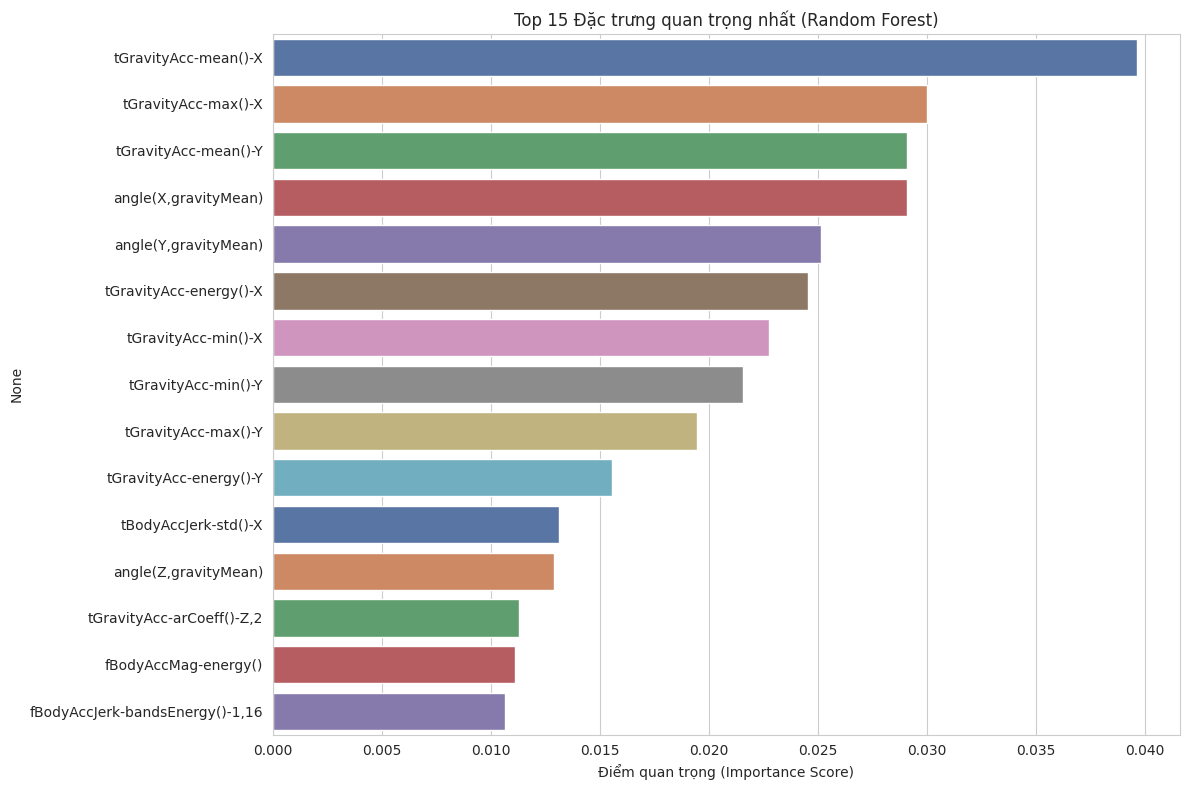

In [ ]:
# 4. TOP 15 ĐẶC TRƯNG QUAN TRỌNG NHẤT

print("\nĐang tính toán độ quan trọng của đặc trưng...")
# Sử dụng Random Forest để đánh giá
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Lấy 15 đặc trưng cao nhất
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(12, 8))
sns.barplot(x=importances[indices], y=X.columns[indices], palette='deep')
plt.title('Top 15 Đặc trưng quan trọng nhất (Random Forest)')
plt.xlabel('Điểm quan trọng (Importance Score)')
plt.tight_layout()
plt.show()


Biểu đồ Top 15 đặc trưng quan trọng nhất cho thấy các đặc trưng liên quan đến gia tốc trọng lực và góc nghiêng so với trọng lực giữ vai trò chủ đạo trong phân loại hành động. Trong đó, tGravityAcc-mean()-X là đặc trưng quan trọng nhất, phản ánh vai trò nổi bật của trục X trong việc phân biệt các trạng thái vận động.

Bên cạnh đó, các đặc trưng về năng lượng tín hiệu giúp mô hình nhận diện rõ các hoạt động động như đi bộ và lên/xuống cầu thang. Các đặc trưng jerk và hệ số AR tuy có mức ảnh hưởng thấp hơn nhưng vẫn góp phần bổ sung thông tin về biến đổi chuyển động.

Kết luận:
Gia tốc trọng lực và góc nghiêng là nhóm đặc trưng quan trọng nhất, phản ánh đúng bản chất vật lý của chuyển động và cho thấy tập đặc trưng đầu vào được xây dựng hợp lý, góp phần nâng cao hiệu quả phân loại của mô hình Random Forest.


Đang chạy t-SNE


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


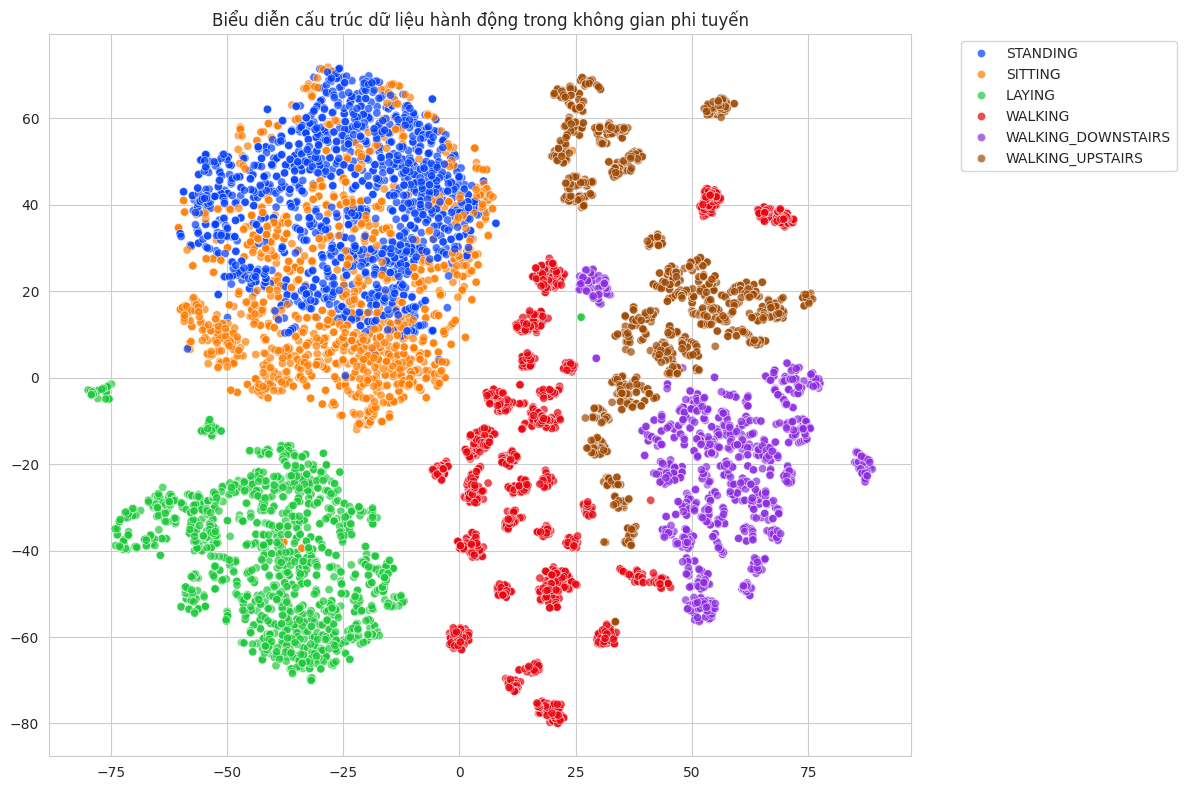

In [ ]:
# 5. t-SNE VISUALIZATION
print("\nĐang chạy t-SNE")
# dùng toàn bộ tập train
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(12, 8))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='bright', alpha=0.7)
plt.title('Biểu diễn cấu trúc dữ liệu hành động trong không gian phi tuyến')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()


Biểu đồ biểu diễn cấu trúc dữ liệu hành động trong không gian phi tuyến thể hiện rõ sự phân tách không gian đặc trưng giữa các nhóm hành động, trong đó mỗi màu đại diện cho một lớp hành vi.

LAYING (xanh lá nhạt):

*   Phân bố cô lập hoàn toàn ở góc dưới bên trái.
*   Gần như không chồng lấn với bất kỳ lớp nào khác.
*   Điều này cho thấy tư thế nằm có đặc trưng chuyển động hoàn toàn khác biệt.

STANDING và SITTING (xanh dương – cam):
*   Hai lớp này nằm gần nhau và có sự chồng lấn đáng kể.
*   Điều này phản ánh đúng thực tế vì hai trạng thái đều là hành động tĩnh, chỉ khác nhau ở tư thế.
*   Đây cũng là nguồn gốc chính của sai số phân loại giữa hai lớp này.

WALKING (đỏ):
*   Phân bố thành các cụm nhỏ dọc theo vùng trung tâm, phản ánh tính biến thiên cao của hành vi đi bộ trên mặt phẳng.

WALKING_UPSTAIRS (nâu) và WALKING_DOWNSTAIRS (tím):
*   Hai lớp nằm ở phía bên phải không gian đặc trưng.
*  Có một mức độ chồng lấn cục bộ, do hai hoạt động này có chuyển động gần tương đồng về biên độ nhưng khác về chiều hướng lực tác động.

Kết luận

Biểu đồ phân cụm phi tuyến cho thấy không gian đặc trưng của dữ liệu có cấu trúc phân tách rõ ràng, đặc biệt giữa nhóm hành động tĩnh và hành động động. Tuy nhiên, sự chồng lấn giữa STANDING – SITTING và WALKING_UPSTAIRS – WALKING_DOWNSTAIRS phản ánh rõ giới hạn phân biệt tự nhiên giữa các hành động có tính chất vật lý tương đồng.

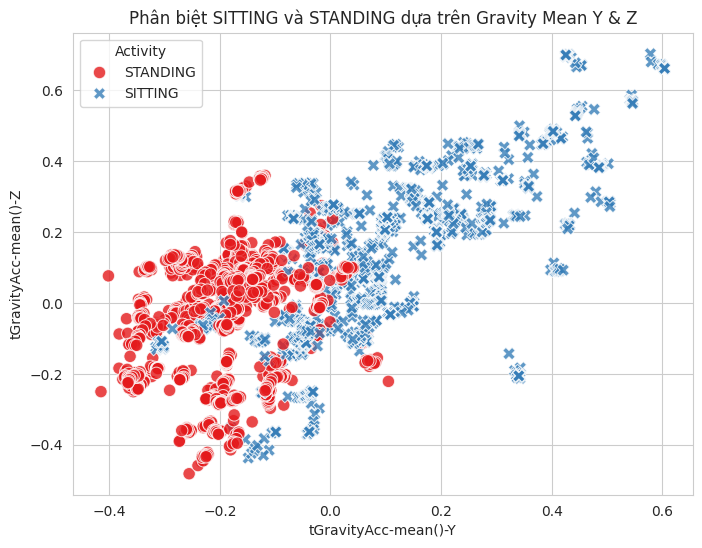

In [ ]:
# 6. PHÂN BIỆT SITTING VS STANDING
# Lọc chỉ 2 hành động này
subset = df[df['Activity'].isin(['SITTING', 'STANDING'])]

plt.figure(figsize=(8, 6))
sns.scatterplot(x='tGravityAcc-mean()-Y', y='tGravityAcc-mean()-Z',
                hue='Activity', style='Activity', data=subset, s=80, alpha=0.8, palette='Set1')
plt.title('Phân biệt SITTING và STANDING dựa trên Gravity Mean Y & Z')
plt.xlabel('tGravityAcc-mean()-Y')
plt.ylabel('tGravityAcc-mean()-Z')
plt.show()

Biểu đồ phân tán cho thấy hai hoạt động SITTING và STANDING có sự chồng lấn đáng kể trên hai trục tGravityAcc-mean()-Y và tGravityAcc-mean()-Z. Tuy nhiên, vẫn tồn tại xu hướng tách biệt tương đối, trong đó SITTING có xu hướng phân bố về phía giá trị Y, Z lớn hơn so với STANDING. Điều này phản ánh sự khác biệt tinh tế về tư thế cơ thể và phân bố trọng lực, đồng thời lý giải vì sao hai lớp này thường dễ gây nhầm lẫn trong bài toán phân loại.

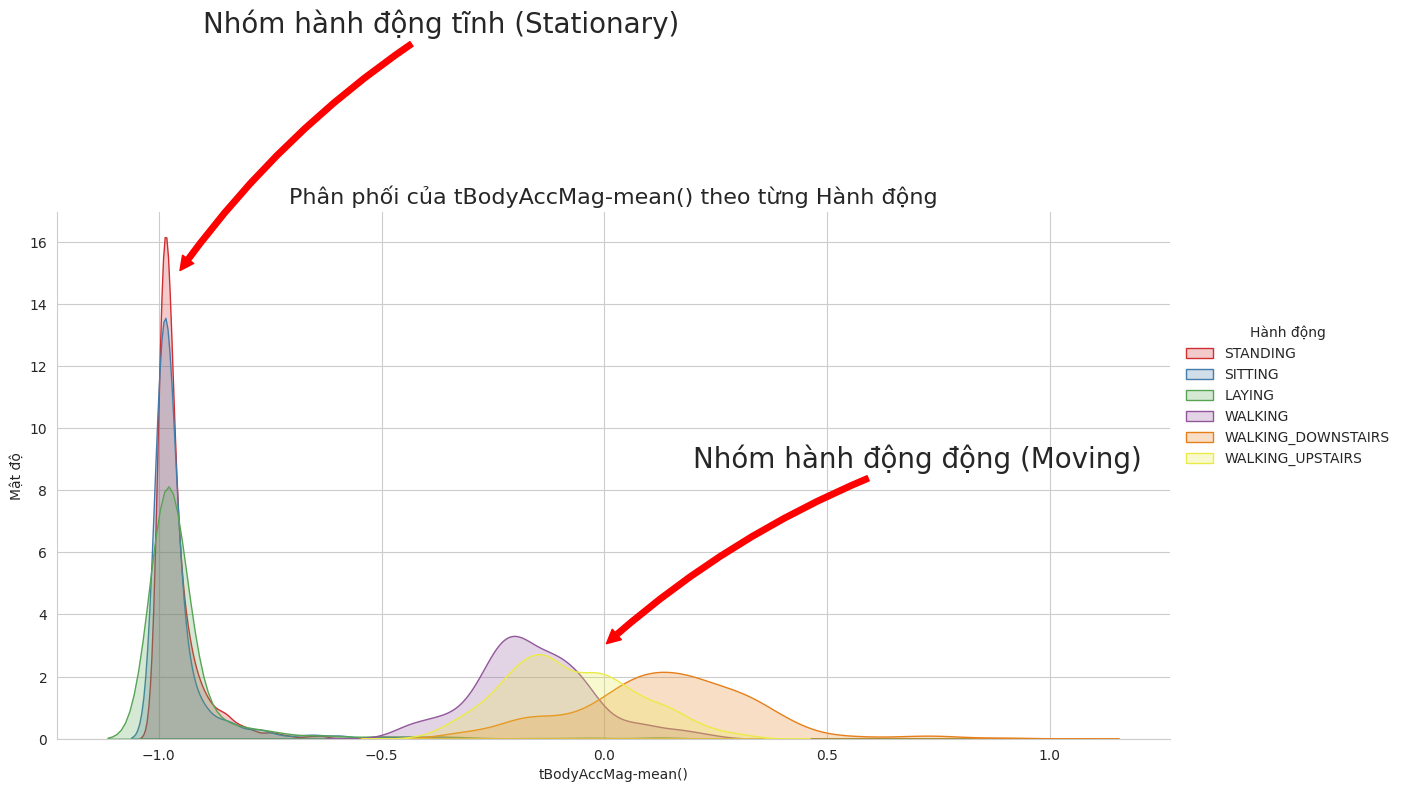

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = df.copy()

if 'Activity' in plot_df.columns:
    plot_df = plot_df.rename(columns={'Activity': 'Hành động'})

col_name = 'tBodyAccMag-mean()'

# Kiểm tra xem cột dữ liệu vẽ có tồn tại không
if col_name not in plot_df.columns:
    print(f"Lưu ý: Không tìm thấy cột '{col_name}'. Đang thử tìm tên cột tương tự...")
    candidates = [c for c in plot_df.columns if 'BodyAccMag' in c and 'mean' in c]
    if candidates:
        col_name = candidates[0]
        print(f"-> Đã chuyển sang dùng cột: {col_name}")
    else:
        print("-> Không tìm thấy cột phù hợp để vẽ biểu đồ.")
        col_name = None


if col_name:
    # Thiết lập màu sắc
    sns.set_palette("Set1", desat=0.80)

    facetgrid = sns.FacetGrid(plot_df, hue='Hành động', height=6, aspect=2)

    # Vẽ biểu đồ mật độ
    facetgrid.map(sns.kdeplot, col_name, fill=True)

    # Thêm chú thích
    facetgrid.add_legend()

    # Thêm mũi tên chú thích
    plt.annotate("Nhóm hành động tĩnh (Stationary)", xy=(-0.956, 15), xytext=(-0.9, 23), size=20,
                va='center', ha='left',
                arrowprops=dict(arrowstyle="simple", connectionstyle="arc3,rad=0.1", color='red'))

    plt.annotate("Nhóm hành động động (Moving)", xy=(0, 3), xytext=(0.2, 9), size=20,
                va='center', ha='left',
                arrowprops=dict(arrowstyle="simple", connectionstyle="arc3,rad=0.1", color='red'))

    facetgrid.set_axis_labels(col_name, "Mật độ")

plt.title(f"Phân phối của {col_name} theo từng Hành động", fontsize=16)
plt.show()



Biểu đồ mật độ của tBodyAccMag-mean() cho thấy sự phân tách rất rõ giữa nhóm hoạt động tĩnh (STANDING, SITTING, LAYING) và nhóm hoạt động động (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS). Nhóm tĩnh tập trung quanh giá trị thấp (x ≈ –1) với độ phân tán nhỏ, phản ánh mức gia tốc ổn định; trong khi nhóm động phân bố về phía giá trị lớn hơn (x ≈ –0.3 đến 0.4) với độ phân tán rộng, thể hiện dao động mạnh. Đặc trưng này có khả năng phân tách rất tốt giữa hai nhóm hoạt động, nhưng chưa đủ để phân biệt chi tiết các hành động tương đồng trong cùng nhóm do còn hiện tượng chồng lấn.

#1D CNN-BiLSTM

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Các thư viện Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Reshape, Input, Concatenate
from tensorflow.keras.layers import Conv1D, MaxPooling1D, BatchNormalization # Các lớp cho CNN
from tensorflow.keras.layers import LSTM, Bidirectional # Các lớp cho RNN
from tensorflow.keras.optimizers import Adam # Thuật toán tối ưu hóa
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint # Callbacks để kiểm soát huấn luyện
from tensorflow.keras.utils import to_categorical # Chuyển đổi nhãn sang one-hot

# Thiết lập seed để đảm bảo kết quả có thể tái lập
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
def load_and_process_data(train_path, test_path):
    """
    Hàm đọc dữ liệu, tách nhãn, chuẩn hóa và reshape.
    """
    # 1. Đọc dữ liệu từ file CSV
    print("Đang tải dữ liệu...")
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    print(f"Kích thước tập Train gốc: {train_df.shape}")
    print(f"Kích thước tập Test gốc: {test_df.shape}")

    # 2. Tách đặc trưng (X) và nhãn (y)
    # Loại bỏ cột 'subject' (ID người dùng) để tránh mô hình học thuộc lòng người dùng cụ thể
    # Loại bỏ cột 'Activity' vì đây là nhãn cần dự đoán
    X_train_raw = train_df.drop(['subject', 'Activity'], axis=1)
    y_train_raw = train_df['Activity']

    X_test_raw = test_df.drop(['subject', 'Activity'], axis=1)
    y_test_raw = test_df['Activity']

    # 3. Mã hóa nhãn (Label Encoding)
    # Chuyển đổi nhãn chuỗi (ví dụ: 'STANDING') thành số nguyên (0, 1, 2...)
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train_raw) # Fit và transform tập train
    y_test_enc = le.transform(y_test_raw)       # Chỉ transform tập test dựa trên mapping của tập train

    # Lưu lại tên các class để dùng cho báo cáo sau này
    target_names = le.classes_
    print("Các nhãn hành động:", target_names)

    # 4. Chuẩn hóa dữ liệu (Standard Scaling)
    # Chuyển đổi dữ liệu về phân phối chuẩn (mean=0, std=1).
    # Điều này cực kỳ quan trọng giúp Gradient Descent hội tụ nhanh hơn.
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)

    return X_train_scaled, y_train_enc, X_test_scaled, y_test_enc, target_names

# Thực thi hàm tải dữ liệu (giả định file nằm cùng thư mục)
X_train_full, y_train_full, X_test, y_test, class_names = load_and_process_data('train.csv', 'test.csv')

# --- CHIA TÁCH DỮ LIỆU: TRAIN - VALIDATION - TEST ---
# Yêu cầu đề bài: Chia thành 3 phần. Tập Test gốc giữ nguyên.
# Tập Train gốc sẽ được chia thành Train (huấn luyện) và Validation (kiểm định).
# Tỷ lệ chia: 80% Train - 20% Validation.
# stratify=y_train_full đảm bảo tỷ lệ các lớp hành động trong train và val là cân bằng.

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# 5. Reshape dữ liệu cho mô hình CNN 1D + BiLSTM
# Input shape của Conv1D là (batch_size, steps, channels)
# Ta coi vector 561 đặc trưng là một chuỗi dài 561 bước, mỗi bước có 1 kênh thông tin.
n_timesteps = X_train.shape[1] # 561
n_features = 1

X_train_reshaped = X_train.reshape(X_train.shape[0], n_timesteps, n_features)
X_val_reshaped = X_val.reshape(X_val.shape[0], n_timesteps, n_features)
X_test_reshaped = X_test.reshape(X_test.shape[0], n_timesteps, n_features)

print(f"Kích thước input sau khi reshape (Train): {X_train_reshaped.shape}")

# 6. Chuyển đổi nhãn sang One-Hot Encoding
# Ví dụ: nhãn 0 ->
n_classes = len(class_names)
y_train_cat = to_categorical(y_train, n_classes)
y_val_cat = to_categorical(y_val, n_classes)
y_test_cat = to_categorical(y_test, n_classes)

Đang tải dữ liệu...
Kích thước tập Train gốc: (7352, 563)
Kích thước tập Test gốc: (2947, 563)
Các nhãn hành động: ['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']
Kích thước input sau khi reshape (Train): (5881, 561, 1)


## Xây dựng Mô hình Baseline

In [ ]:
def build_baseline_model(input_shape, n_classes):
    """
    Mô hình Baseline: CNN 1D đơn giản.
    Gồm 2 lớp tích chập và 1 lớp Dense.
    """
    model = Sequential(name="Baseline_CNN")

    # Lớp Conv1D thứ nhất: 32 bộ lọc, kích thước kernel 3
    model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2)) # Giảm chiều dữ liệu đi 2 lần

    model.add(Flatten()) # Duỗi phẳng dữ liệu để đưa vào lớp Dense
    model.add(Dense(64, activation='relu')) # Lớp ẩn
    model.add(Dense(n_classes, activation='softmax')) # Lớp đầu ra

    # Biên dịch mô hình
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

baseline_model = build_baseline_model((n_timesteps, n_features), n_classes)
baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 559, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 279, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8928)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       571,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 571,974 (2.18 MB)

 Trainable params: 571,974 (2.18 MB)

 Non-trainable params: 0 (0.00 B)

Khởi tạo mô hình tuần tự(Sequential Model)


Lớp tích chập 1D đầu tiên: Lớp Conv1D (32 filters, kernel 3, ReLU): Trích xuất 32 đặc trưng từ dữ liệu chuỗi 1 chiều.

Lớp gộp tối đa 1D: Lớp MaxPooling1D (pool_size=2): Giảm chiều dữ liệu, chọn lọc các đặc trưng quan trọng nhất.

Lớp làm phẳng:Lớp Flatten: Chuyển đổi đầu ra từ các lớp tích chập thành một vector 1 chiều.

Lớp kết nối đầy đủ ẩn: Lớp Dense (64 nơ-ron, ReLU): Một lớp ẩn để học các mối quan hệ phi tuyến tính.

Lớp đầu ra: Lớp Dense đầu ra (số lớp, Softmax): Phân loại dữ liệu thành các lớp hành động với phân phối xác suất.

biên dịch với trình tối ưu hóa Adam, hàm mất mát categorical_crossentropy và theo dõi accuracy để đánh giá hiệu suất. Cấu trúc này giúp trích xuất các đặc trưng tuần tự và phân loại hành động hiệu quả, đóng vai trò là một điểm tham chiếu cơ bản.

## Xây dựng Mô hình Cải tiến

In [ ]:
def build_hybrid_model(input_shape, n_classes):
    """
    Mô hình Hybrid: CNN 1D kết hợp BiLSTM.
    Cải tiến với BatchNormalization và Dropout.
    """
    model = Sequential(name="Hybrid_CNN_BiLSTM")

    # KHỐI TRÍCH XUẤT ĐẶC TRƯNG (CNN BLOCK)

    # Layer 1: Conv1D
    # filters=64: Học 64 loại đặc trưng khác nhau
    # kernel_size=3: Cửa sổ trượt độ dài 3
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape, padding='same'))
    model.add(BatchNormalization()) # Chuẩn hóa batch
    model.add(MaxPooling1D(pool_size=2)) # Giảm chiều dữ liệu, giữ lại đặc trưng nổi bật nhất
    model.add(Dropout(0.3)) # Tắt 30% nơ-ron để chống overfitting

    # Layer 2: Conv1D sâu hơn
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.3))

    # KHỐI XỬ LÝ CHUỖI (SEQUENCE BLOCK)

    # Layer 3: Bidirectional LSTM
    # BiLSTM đọc chuỗi đặc trưng từ CNN theo cả 2 chiều.
    # return_sequences=False: Chỉ lấy vector trạng thái cuối cùng để phân loại (Many-to-One)
    model.add(Bidirectional(LSTM(64, return_sequences=False)))
    model.add(Dropout(0.4)) # Dropout mạnh hơn ở lớp kết nối đầy đủ

    # KHỐI PHÂN LOẠI (CLASSIFICATION BLOCK)

    # Layer 4: Dense
    model.add(Dense(64, activation='relu'))

    # Output Layer: Softmax
    # Trả về xác suất cho 6 lớp hành động
    model.add(Dense(n_classes, activation='softmax'))

    # Biên dịch mô hình
    # Sử dụng Adam optimizer với learning rate 0.001
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    return model

hybrid_model = build_hybrid_model((n_timesteps, n_features), n_classes)
print("Kiến trúc mô hình Hybrid:")
hybrid_model.summary()

Kiến trúc mô hình Hybrid:


Model: "Hybrid_CNN_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 561, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 561, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 280, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 280, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 280, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 280, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 140, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 140, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,190 (520.27 KB)

 Trainable params: 132,806 (518.77 KB)

 Non-trainable params: 384 (1.50 KB)

## QUY TRÌNH HUẤN LUYỆN

In [ ]:
# Thiết lập Callbacks
early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('best_hybrid_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)

print("\n--- BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH HYBRID ---")
history = hybrid_model.fit(
    X_train_reshaped, y_train_cat,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_reshaped, y_val_cat),
    callbacks=[early_stop, checkpoint],
    verbose=1
)


--- BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH HYBRID ---
Epoch 1/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5721 - loss: 0.9840
Epoch 1: val_accuracy improved from -inf to 0.50034, saving model to best_hybrid_model.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.5727 - loss: 0.9825 - val_accuracy: 0.5003 - val_loss: 1.3982
Epoch 2/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8267 - loss: 0.4327
Epoch 2: val_accuracy improved from 0.50034 to 0.78246, saving model to best_hybrid_model.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8267 - loss: 0.4325 - val_accuracy: 0.7825 - val_loss: 0.5041
Epoch 3/50
181/184 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8766 - loss: 0.3148
Epoch 3: val_accuracy improved from 0.78246 to 0.91366, saving model to best_hybrid_model.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8767 - loss: 0.3146 - val_accuracy: 0.9137 - val_loss: 0.2121
Epoch 4/50
183/184 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9032 - loss: 0.2480
Epoch 4: val_accuracy improved from 0.91366 to 0.91978, saving model to best_hybrid_model.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9031 - loss: 0.2480 - val_accuracy: 0.9198 - val_loss: 0.1969
Epoch 5/50
183/184 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9120 - loss: 0.2278
Epoch 5: val_accuracy improved from 0.91978 to 0.93202, saving model to best_hybrid_model.h5


...

184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9713 - loss: 0.0768 - val_accuracy: 0.9633 - val_loss: 0.0935
Epoch 36/50
183/184 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9706 - loss: 0.0759
Epoch 36: val_accuracy improved from 0.96329 to 0.96397, saving model to best_hybrid_model.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9706 - loss: 0.0760 - val_accuracy: 0.9640 - val_loss: 0.0852
Epoch 37/50
181/184 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9728 - loss: 0.0722
Epoch 37: val_accuracy did not improve from 0.96397
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9728 - loss: 0.0722 - val_accuracy: 0.9626 - val_loss: 0.0850
Epoch 38/50
181/184 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9693 - loss: 0.0755
Epoch 38: val_accuracy did not improve from 0.96397
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9692 - loss: 0.0756 - val_accuracy: 0.9436 - val_loss: 0.1389
Epoch 39/50
181/184 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9704 - loss: 0.0778
Epoch 39: val_accuracy did not improve from 0.96397
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9704 - loss: 0.0778 - val_accuracy: 0.9565 - val_loss: 0.1012
Epoch 40/50
181/184 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9707 - loss: 0.0727
Epoch 40: val_accura

184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9706 - loss: 0.0728 - val_accuracy: 0.9653 - val_loss: 0.0879
Epoch 41/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9716 - loss: 0.0725
Epoch 41: val_accuracy improved from 0.96533 to 0.96737, saving model to best_hybrid_model.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9716 - loss: 0.0725 - val_accuracy: 0.9674 - val_loss: 0.0899
Epoch 42/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9736 - loss: 0.0676
Epoch 42: val_accuracy did not improve from 0.96737
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9736 - loss: 0.0677 - val_accuracy: 0.9545 - val_loss: 0.1001
Epoch 43/50
182/184 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9732 - loss: 0.0699
Epoch 43: val_accuracy did not improve from 0.96737
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9732 - loss: 0.0699 - val_accuracy: 0.9674 - val_loss: 0.0991
Epoch 44/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9751 - loss: 0.0618
Epoch 44: val_accuracy did not improve from 0.96737
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9751 - loss: 0.0618 - val_accuracy: 0.9667 - val_loss: 0.0858
Epoch 45/50
183/184 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9803 - loss: 0.0534
Epoch 45: val_accura

184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9803 - loss: 0.0535 - val_accuracy: 0.9728 - val_loss: 0.0832
Epoch 46/50
183/184 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9790 - loss: 0.0579
Epoch 46: val_accuracy did not improve from 0.97281
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9790 - loss: 0.0580 - val_accuracy: 0.9660 - val_loss: 0.0838
Epoch 47/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9788 - loss: 0.0583
Epoch 47: val_accuracy did not improve from 0.97281
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9788 - loss: 0.0583 - val_accuracy: 0.9687 - val_loss: 0.0827
Epoch 48/50
183/184 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9776 - loss: 0.0580
Epoch 48: val_accuracy did not improve from 0.97281
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9776 - loss: 0.0580 - val_accuracy: 0.9613 - val_loss: 0.1029
Epoch 49/50
183/184 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9770 - loss: 0.0582
Epoch 49: val_accura

In [ ]:
# Thiết lập Callbacks
early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)
checkpoint_baseline = ModelCheckpoint('best_baseline_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)

# Tạo tf.data.Dataset giải quyết lỗi cardinality
batch_size = 32
train_dataset_tf = tf.data.Dataset.from_tensor_slices((X_train_reshaped, y_train_cat)).batch(batch_size)
val_dataset_tf = tf.data.Dataset.from_tensor_slices((X_val_reshaped, y_val_cat)).batch(batch_size)

print("\n--- BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH BASELINE ---")
history_baseline_model = baseline_model.fit(
    train_dataset_tf,
    epochs=50,
    validation_data=val_dataset_tf,
    callbacks=[early_stop, checkpoint_baseline],
    verbose=1
)


--- BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH BASELINE ---
Epoch 1/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7991 - loss: 0.4848
Epoch 1: val_accuracy improved from -inf to 0.95105, saving model to best_baseline_model.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.7996 - loss: 0.4836 - val_accuracy: 0.9511 - val_loss: 0.1306
Epoch 2/50
173/184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9615 - loss: 0.1022
Epoch 2: val_accuracy improved from 0.95105 to 0.95581, saving model to best_baseline_model.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9615 - loss: 0.1020 - val_accuracy: 0.9558 - val_loss: 0.1138
Epoch 3/50
170/184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9745 - loss: 0.0740
Epoch 3: val_accuracy did not improve from 0.95581
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9744 - loss: 0.0738 - val_accuracy: 0.9415 - val_loss: 0.1295
Epoch 4/50
172/184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9790 - loss: 0.0657
Epoch 4: val_accuracy did not improve from 0.95581
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9792 - loss: 0.0649 - val_accuracy: 0.9524 - val_loss: 0.1170
Epoch 5/50
172/184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9839 - loss: 0.0504
Epoch 5: val_accuracy did not improve from 0.95581
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9840 - loss: 0.0499 - val_accuracy: 0.9477 - val_loss: 0.1279
Epoch 6/50
172/184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9846 - loss: 0.0435
Epoch 6: val_accuracy did not impro

184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9874 - loss: 0.0351 - val_accuracy: 0.9572 - val_loss: 0.1059
Epoch 8/50
169/184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9903 - loss: 0.0294
Epoch 8: val_accuracy improved from 0.95717 to 0.96465, saving model to best_baseline_model.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9904 - loss: 0.0289 - val_accuracy: 0.9646 - val_loss: 0.0954
Epoch 9/50
173/184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9928 - loss: 0.0244
Epoch 9: val_accuracy improved from 0.96465 to 0.97485, saving model to best_baseline_model.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9928 - loss: 0.0243 - val_accuracy: 0.9748 - val_loss: 0.0698
Epoch 10/50
172/184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9944 - loss: 0.0188
Epoch 10: val_accuracy improved from 0.97485 to 0.98436, saving model to best_baseline_model.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9944 - loss: 0.0188 - val_accuracy: 0.9844 - val_loss: 0.0474
Epoch 11/50
173/184 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9962 - loss: 0.0142
Epoch 11: val_accuracy improved from 0.98436 to 0.98844, saving model to best_baseline_model.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9962 - loss: 0.0140 - val_accuracy: 0.9884 - val_loss: 0.0367
Epoch 12/50
182/184 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9978 - loss: 0.0104
Epoch 12: val_accuracy did not improve from 0.98844
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9978 - loss: 0.0104 - val_accuracy: 0.9844 - val_loss: 0.0363
Epoch 13/50
182/184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9975 - loss: 0.0102
Epoch 13: val_accuracy did not improve from 0.98844
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9975 - loss: 0.0102 - val_accuracy: 0.9850 - val_loss: 0.0438
Epoch 14/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9961 - loss: 0.0094
Epoch 14: val_accuracy did not improve from 0.98844
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9961 - loss: 0.0094 - val_accuracy: 0.9803 - val_loss: 0.0538
Epoch 15/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9892 - loss: 0.0287
Epoch 15: val_accuracy did n

## KẾT QUẢ THỰC NGHIỆM VÀ ĐÁNH GIÁ


ĐÁNH GIÁ MÔ HÌNH BASELINE


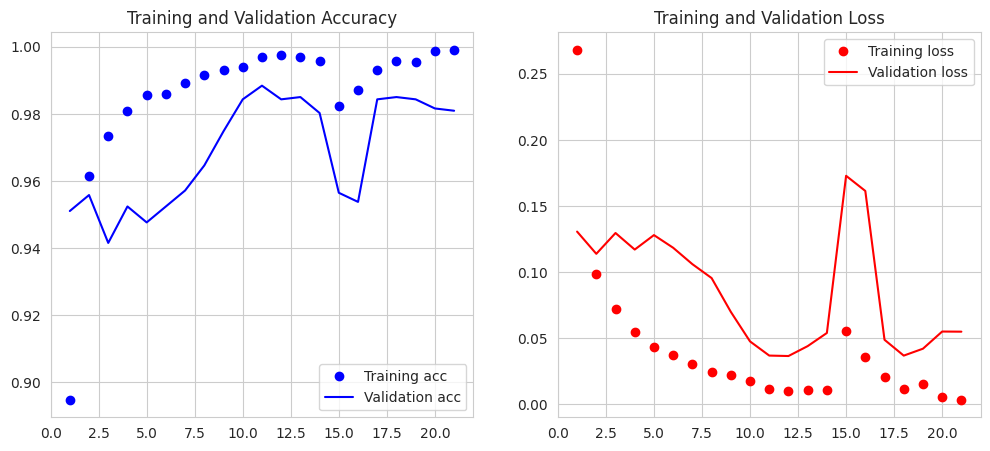

Test Accuracy: 94.98%
Test Loss: 0.1860
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---
                    precision    recall  f1-score   support

            LAYING       0.99      1.00      1.00       537
           SITTING       0.94      0.87      0.91       491
          STANDING       0.89      0.95      0.92       532
           WALKING       0.93      0.99      0.96       496
WALKING_DOWNSTAIRS       0.99      0.95      0.96       420
  WALKING_UPSTAIRS       0.96      0.93      0.95       471

          accuracy                           0.95      2947
         macro avg       0.95      0.95      0.95      2947
      weighted avg       0.95      0.95      0.95      2947



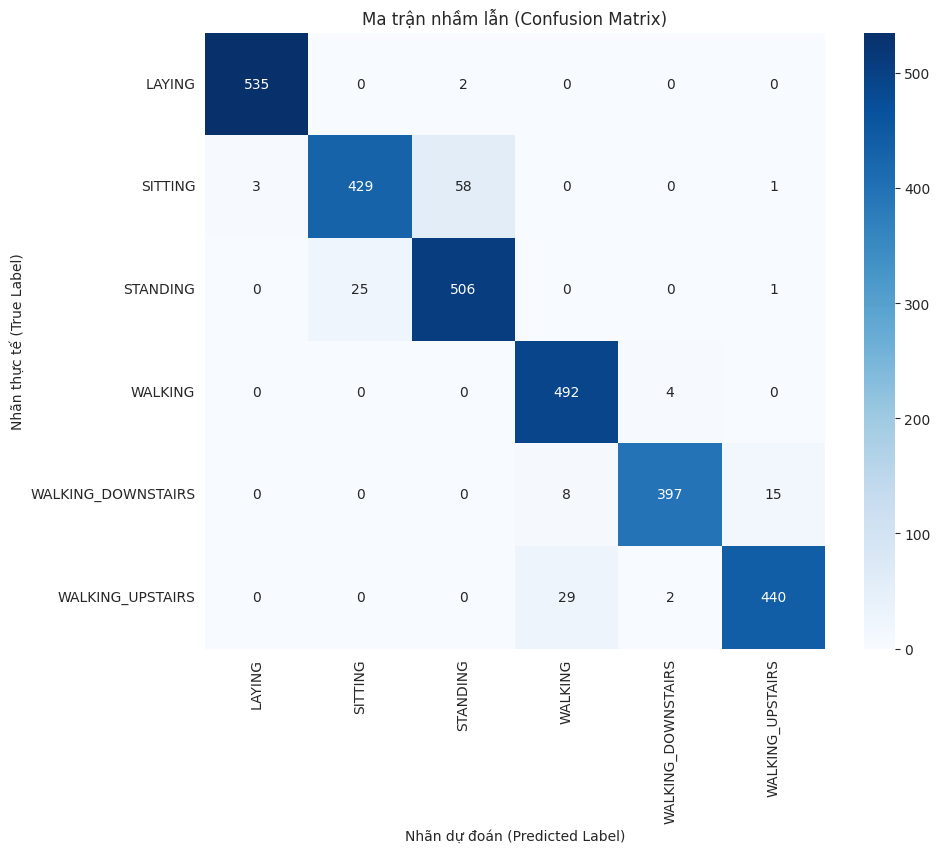

In [ ]:
def plot_history(history):
    """Vẽ biểu đồ quá trình huấn luyện"""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'ro', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()

def evaluate_and_compare(model, X_test, y_test_cat, y_test_labels, class_names):
    # 1. Đánh giá Loss và Accuracy
    loss, acc = model.evaluate(X_test, y_test_cat, verbose=0)
    print(f"Test Accuracy: {acc*100:.2f}%")
    print(f"Test Loss: {loss:.4f}")

    # 2. Dự đoán
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)

    # 3. Classification Report
    print("\n--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---")
    print(classification_report(y_test_labels, y_pred, target_names=class_names))

    # 4. Confusion Matrix
    cm = confusion_matrix(y_test_labels, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
    plt.ylabel('Nhãn thực tế (True Label)')
    plt.xlabel('Nhãn dự đoán (Predicted Label)')
    plt.show()

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# --- ĐÁNH GIÁ MÔ HÌNH BASELINE ---
print("\n" + "="*60)
print("ĐÁNH GIÁ MÔ HÌNH BASELINE")
print("="*60)

# 1. Vẽ biểu đồ huấn luyện của baseline
plot_history(history_baseline_model)

evaluate_and_compare(
    model=baseline_model,
    X_test=X_test_reshaped,
    y_test_cat=y_test_cat,
    y_test_labels=y_test, # Changed from y_test_keras to y_test
    class_names=class_names
)

# baseline

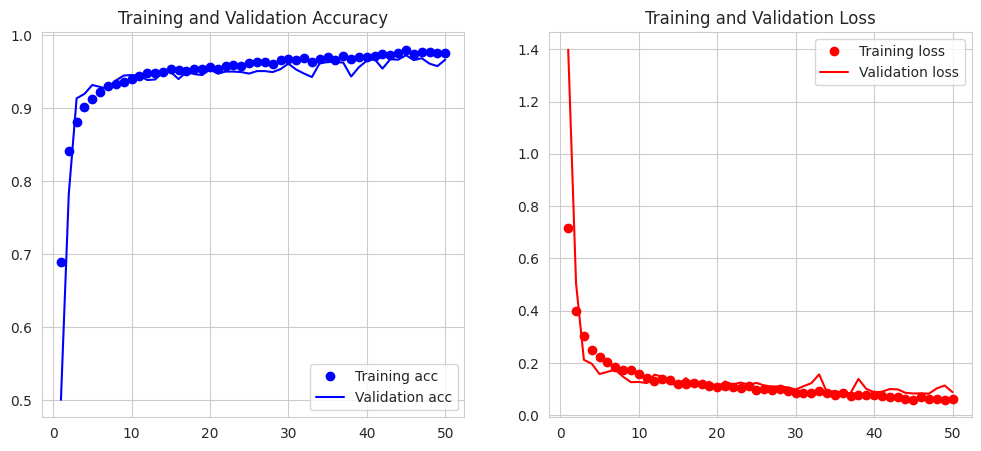

Test Accuracy: 88.84%
Test Loss: 0.5283
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.91      0.79      0.84       491
          STANDING       0.83      0.92      0.87       532
           WALKING       0.85      0.92      0.88       496
WALKING_DOWNSTAIRS       0.92      0.80      0.86       420
  WALKING_UPSTAIRS       0.84      0.87      0.85       471

          accuracy                           0.89      2947
         macro avg       0.89      0.88      0.89      2947
      weighted avg       0.89      0.89      0.89      2947



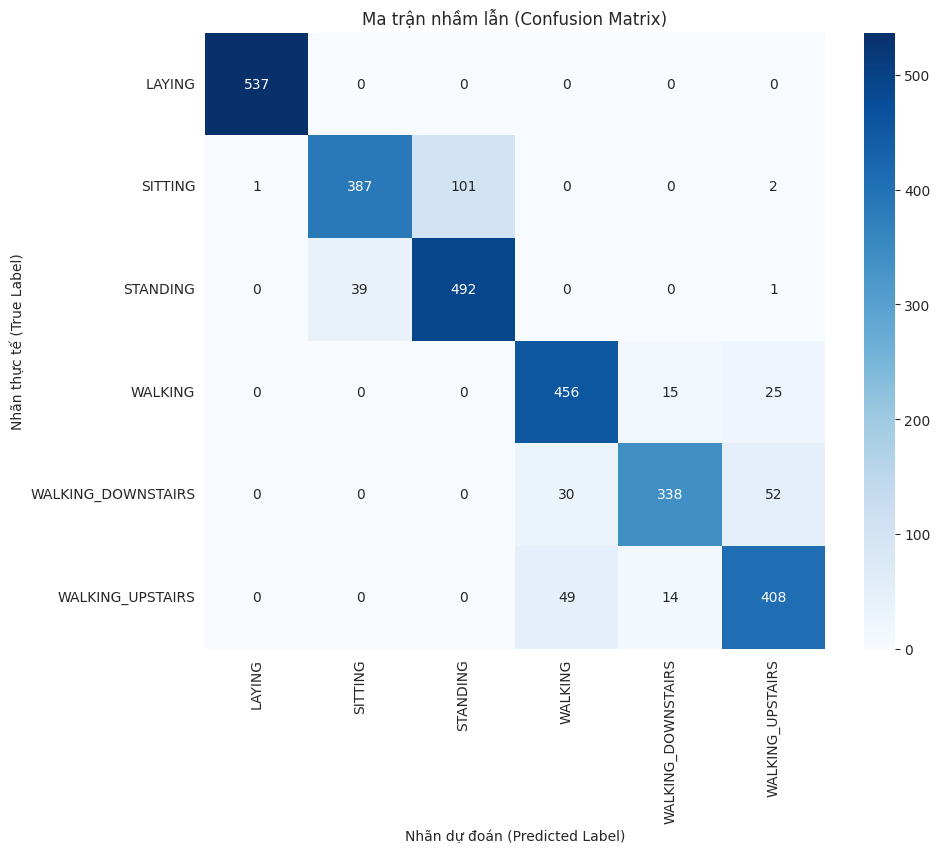

In [ ]:
def plot_history(history):
    """Vẽ biểu đồ quá trình huấn luyện"""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'ro', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()

def evaluate_and_compare(model, X_test, y_test_cat, y_test_labels, class_names):
    # 1. Đánh giá Loss và Accuracy
    loss, acc = model.evaluate(X_test, y_test_cat, verbose=0)
    print(f"Test Accuracy: {acc*100:.2f}%")
    print(f"Test Loss: {loss:.4f}")

    # 2. Dự đoán
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)

    # 3. Classification Report
    print("\n--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---")
    print(classification_report(y_test_labels, y_pred, target_names=class_names))

    # 4. Confusion Matrix
    cm = confusion_matrix(y_test_labels, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
    plt.ylabel('Nhãn thực tế (True Label)')
    plt.xlabel('Nhãn dự đoán (Predicted Label)')
    plt.show()

# Hiển thị biểu đồ huấn luyện
plot_history(history)

# Đánh giá chi tiết
evaluate_and_compare(hybrid_model, X_test_reshaped, y_test_cat, y_test, class_names)

# So sánh mô hình


## CNN 1D-BiLSTM

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

Hai biểu đồ thể hiện quá trình huấn luyện và kiểm định của mô hình cho thấy khả năng học ổn định và ít xảy ra hiện tượng overfitting. Ở biểu đồ bên trái, độ chính xác trên tập huấn luyện và tập kiểm định đều tăng nhanh trong những epoch đầu và dần tiến đến trạng thái ổn định ở mức cao (gần 1.0). Sự chênh lệch giữa training accuracy và validation accuracy rất nhỏ, chứng tỏ mô hình học tốt và không bị lệch nhiều giữa hai tập dữ liệu.

Ở biểu đồ bên phải, giá trị loss của cả huấn luyện và kiểm định đều giảm mạnh trong giai đoạn đầu và tiếp tục giảm từ từ qua các epoch. Validation loss luôn duy trì ở mức xấp xỉ training loss và không có dấu hiệu tăng trở lại, cho thấy mô hình không bị overfit và khả năng tổng quát hóa tốt. Đường cong loss mượt và ổn định cũng phản ánh quá trình tối ưu diễn ra hiệu quả.

Tổng thể, các biểu đồ cho thấy mô hình học nhanh, hội tụ tốt và đạt hiệu năng cao trên cả tập huấn luyện lẫn tập kiểm định. Điều này khẳng định mô hình phù hợp cho bài toán nhận dạng hành động trên dữ liệu cảm biến.

### CNN 1D-BiLSTM -Test Accuracy: 88.36%

Ma trận nhầm lẫn cho thấy mô hình đạt độ chính xác 88%, phân loại rất tốt các hành động rõ ràng như LAYING và WALKING, với recall cao trên 0.90. Tuy nhiên, mô hình còn nhầm lẫn giữa các tư thế tĩnh SITTING và STANDING, cũng như giữa các hành động bước đi UPSTAIRS và DOWNSTAIRS, do tín hiệu cảm biến tương đối giống nhau. Nhìn chung, các chỉ số F1-score trung bình đạt 0.88, chứng tỏ mô hình hoạt động ổn định và phân loại khá chính xác trên toàn bộ 6 hành động.

## LSTM

In [ ]:
# thư viện
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import plot_model, to_categorical


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
from sklearn.preprocessing import LabelEncoder


In [ ]:

train_df = pd.read_csv("train_scaled.csv")
test_df = pd.read_csv("test_scaled.csv")

X_train = train_df.drop("Activity", axis=1).values
y_train = train_df["Activity"].values

X_test = test_df.drop("Activity", axis=1).values
y_test = test_df["Activity"].values

In [ ]:
# Encode labels
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test  = le.transform(y_test)


In [ ]:
# Split train/val
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)


In [ ]:

# ĐỔI TÊN CHO ĐÚNG (để dùng cho PyTorch)
X_train_final = X_train
X_val_final   = X_val
X_test_final  = X_test

y_train_final = y_train
y_val_final   = y_val
y_test_final  = y_test

In [ ]:
import torch

# Chuyển đổi mảng NumPy sang tensor PyTorch và thêm chiều độ dài chuỗi cho LSTM
X_train = torch.tensor(X_train_final, dtype=torch.float32).unsqueeze(1)
X_val   = torch.tensor(X_val_final, dtype=torch.float32).unsqueeze(1)
X_test  = torch.tensor(X_test_final, dtype=torch.float32).unsqueeze(1)

# Chuyển đổi nhãn từ NumPy sang tensor kiểu LongTensor cho bài toán phân loại
y_train = torch.tensor(y_train_final, dtype=torch.long)
y_val   = torch.tensor(y_val_final, dtype=torch.long)
y_test  = torch.tensor(y_test_final, dtype=torch.long)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: torch.Size([5881, 1, 562])
X_val shape: torch.Size([1471, 1, 562])
X_test shape: torch.Size([2947, 1, 562])
y_train shape: torch.Size([5881])
y_val shape: torch.Size([1471])
y_test shape: torch.Size([2947])


In [ ]:
# 2. DataLoader
batch_size = 64
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)
test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size)


In [ ]:
# 3. PureLSTM model
class PureLSTM(nn.Module):
    def __init__(self, input_size, num_classes):
        super(PureLSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=128,
            num_layers=1,
            batch_first=True
        )
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        # x: (batch, seq_len=1, input_size)
        if x.dim() == 2:
            x = x.unsqueeze(1)
        out, (hn, cn) = self.lstm(x)
        out = hn[-1]
        out = self.fc(out)
        return out

In [ ]:
# 4. Train & Validate function

def train_and_validate(model, train_loader, val_loader, num_epochs):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(num_epochs):
        # TRAIN
        model.train()
        running_loss = 0
        correct_train = 0
        total_train = 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X.size(0)
            _, preds = torch.max(outputs, 1)
            correct_train += (preds == y).sum().item()
            total_train += y.size(0)

        train_loss = running_loss / total_train
        train_acc = correct_train / total_train

        # VALIDATION
        model.eval()
        val_loss_total = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                outputs = model(X)
                loss = criterion(outputs, y)

                val_loss_total += loss.item() * X.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == y).sum().item()
                val_total += y.size(0)

        val_loss = val_loss_total / val_total
        val_acc = val_correct / val_total

        # LƯU LỊCH SỬ
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        # IN RA MỖI EPOCH
        print(f"Epoch [{epoch+1}/{num_epochs}] | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    return history

In [ ]:
# 5. Khởi tạo model, criterion, optimizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_size = X_train.shape[2]   # Should be 1 after unsqueeze(1)
num_classes = len(le.classes_)  # 6

lstm_model = PureLSTM(input_size=input_size, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer_lstm = optim.Adam(lstm_model.parameters(), lr=0.001)

NUM_EPOCHS = 50
# 6. Train
def train_and_validate(
    model, train_loader, val_loader,
    criterion, optimizer,
    num_epochs,
    patience=10,
    checkpoint_path="best_lstm_model.pt"
):
    device = next(model.parameters()).device
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(num_epochs):

        # ===== TRAIN =====
        model.train()
        running_loss = 0
        correct_train = 0
        total_train = 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X.size(0)
            _, preds = torch.max(outputs, 1)
            correct_train += (preds == y).sum().item()
            total_train += y.size(0)

        train_loss = running_loss / total_train
        train_acc = correct_train / total_train

        # ===== VALIDATION =====
        model.eval()
        val_loss_total = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val, y_val = X_val.to(device), y_val.to(device)
                outputs = model(X_val)
                loss = criterion(outputs, y_val)

                val_loss_total += loss.item() * X_val.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == y_val).sum().item()
                val_total += y_val.size(0)

        val_loss = val_loss_total / val_total
        val_acc = val_correct / val_total

        # ===== LƯU HISTORY =====
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        # ===== EARLY STOPPING + CHECKPOINT =====
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), checkpoint_path)
            print(" Saved best model")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(" Early stopping triggered")
                break

    return history



In [ ]:
history_lstm_model = train_and_validate(lstm_model, train_loader, val_loader, criterion, optimizer_lstm, NUM_EPOCHS)

# 2. Test
lstm_model.eval()
correct = total = 0
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        outputs = lstm_model(X)
        _, pred = torch.max(outputs, 1)
        correct += (pred == y).sum().item()
        total += y.size(0)

print(f"Test Accuracy: {100*correct/total:.2f}%")



Epoch [1/50] | Train Loss: 0.6065 | Val Loss: 0.2478 | Train Acc: 0.8485 | Val Acc: 0.9381
 Saved best model
Epoch [2/50] | Train Loss: 0.1619 | Val Loss: 0.1257 | Train Acc: 0.9589 | Val Acc: 0.9660
 Saved best model
Epoch [3/50] | Train Loss: 0.0928 | Val Loss: 0.1013 | Train Acc: 0.9745 | Val Acc: 0.9674
 Saved best model
Epoch [4/50] | Train Loss: 0.0690 | Val Loss: 0.0792 | Train Acc: 0.9789 | Val Acc: 0.9762
 Saved best model
Epoch [5/50] | Train Loss: 0.0521 | Val Loss: 0.0740 | Train Acc: 0.9845 | Val Acc: 0.9755
 Saved best model
Epoch [6/50] | Train Loss: 0.0443 | Val Loss: 0.0734 | Train Acc: 0.9878 | Val Acc: 0.9728
 Saved best model
Epoch [7/50] | Train Loss: 0.0398 | Val Loss: 0.0673 | Train Acc: 0.9852 | Val Acc: 0.9769
 Saved best model
Epoch [8/50] | Train Loss: 0.0322 | Val Loss: 0.0681 | Train Acc: 0.9906 | Val Acc: 0.9769
Epoch [9/50] | Train Loss: 0.0307 | Val Loss: 0.0595 | Train Acc: 0.9912 | Val Acc: 0.9762
 Saved best model
Epoch [10/50] | Train Loss: 0.0287 | 

Mô hình LSTM được xây dựng cho bài toán phân loại chuỗi với dữ liệu đầu vào có dạng (N, 562, 1), trong đó mỗi mẫu gồm 562 bước thời gian và một đặc trưng tại mỗi bước. Dữ liệu sau khi được chuẩn hóa và tổ chức thành chuỗi được đưa trực tiếp vào các lớp LSTM nhằm học các phụ thuộc theo thời gian dài hạn. Đầu ra của LSTM được làm phẳng và đưa qua các lớp fully-connected để thực hiện phân loại thành 6 lớp. Quá trình huấn luyện sử dụng hàm mất mát CrossEntropyLoss và bộ tối ưu Adam, kết hợp tập validation để theo dõi hiệu suất mô hình. Các chỉ số loss và accuracy trên tập huấn luyện và validation được ghi nhận theo từng epoch nhằm đánh giá khả năng hội tụ và mức độ overfitting của mô hình.

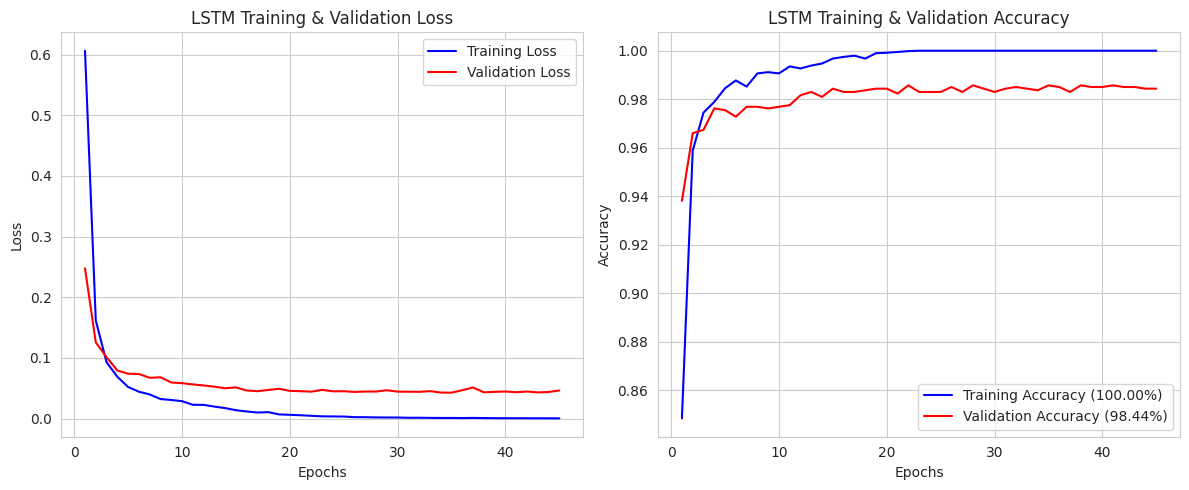

In [ ]:
import matplotlib.pyplot as plt

# Lấy dữ liệu từ history
loss = history_lstm_model['train_loss']
val_loss = history_lstm_model['val_loss']
acc = history_lstm_model['train_acc']
val_acc = history_lstm_model['val_acc']
epochs = range(1, len(loss) + 1)

final_train_acc = acc[-1] * 100
final_val_acc = val_acc[-1] * 100

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('LSTM Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, acc, 'b', label=f'Training Accuracy ({final_train_acc:.2f}%)')
plt.plot(epochs, val_acc, 'r', label=f'Validation Accuracy ({final_val_acc:.2f}%)')
plt.title('LSTM Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Biểu đồ cho thấy mô hình LSTM học rất nhanh và ổn định. Loss của cả training và validation đều giảm mạnh trong 10 epoch đầu và sau đó duy trì ở mức thấp, chứng tỏ mô hình đã hội tụ tốt. Accuracy tăng nhanh lên trên 98% ở validation và gần 100% ở training, cho thấy mô hình học hiệu quả các đặc trưng chuỗi thời gian. Tuy nhiên, khoảng cách nhỏ giữa training accuracy (100%) và validation accuracy (~98.8%) cho thấy mô hình có dấu hiệu hơi overfit nhẹ, nhưng không nghiêm trọng. Nhìn chung, LSTM hoạt động rất tốt và mang lại độ chính xác cao trong bài toán nhận dạng hành động.

### LSTM -Test Accuracy: 94.88%

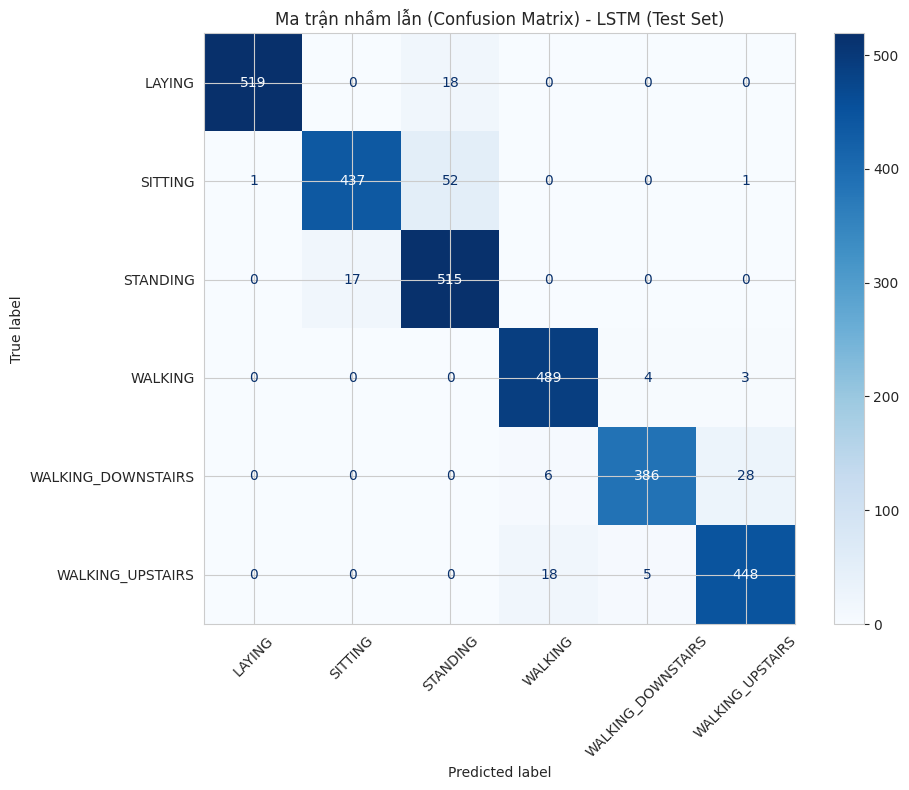


========== BÁO CÁO PHÂN LOẠI CHI TIẾT ==========

                    precision    recall  f1-score   support

            LAYING       1.00      0.97      0.98       537
           SITTING       0.96      0.89      0.92       491
          STANDING       0.88      0.97      0.92       532
           WALKING       0.95      0.99      0.97       496
WALKING_DOWNSTAIRS       0.98      0.92      0.95       420
  WALKING_UPSTAIRS       0.93      0.95      0.94       471

          accuracy                           0.95      2947
         macro avg       0.95      0.95      0.95      2947
      weighted avg       0.95      0.95      0.95      2947



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import torch
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 32

# 1. Lấy toàn bộ dự đoán trên test set
y_true = []
y_pred = []

X_test_for_lstm = torch.tensor(X_test_final, dtype=torch.float32).unsqueeze(1)  # (N, 1, 561)
y_test_for_lstm = torch.tensor(y_test_final, dtype=torch.long)

test_dataset_lstm = TensorDataset(X_test_for_lstm, y_test_for_lstm)
test_loader_lstm = DataLoader(
    test_dataset_lstm,
    batch_size=BATCH_SIZE,
    shuffle=False
)

lstm_model.eval()
with torch.no_grad():
    for X, y in test_loader_lstm:
        X, y = X.to(device), y.to(device)
        outputs = lstm_model(X)
        _, preds = torch.max(outputs, 1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Nhãn lớp
activity_labels = le.classes_

# 2. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=activity_labels
)

disp.plot(
    cmap="Blues",
    ax=ax,
    xticks_rotation=45
)

ax.set_title("Ma trận nhầm lẫn (Confusion Matrix) - LSTM (Test Set)")
plt.tight_layout()
plt.show()

# 3. Classification Report
print("\n========== BÁO CÁO PHÂN LOẠI CHI TIẾT ==========\n")
print(classification_report(y_true, y_pred, target_names=activity_labels))


Biểu đồ Confusion Matrix và Classification Report cho thấy mô hình LSTM đạt hiệu quả phân loại rất tốt trên tập kiểm tra, với độ chính xác tổng thể (accuracy) khoảng 95%. Phần lớn các mẫu được dự đoán đúng, thể hiện qua các giá trị lớn nằm trên đường chéo chính của ma trận nhầm lẫn. Các hoạt động LAYING và WALKING được nhận diện chính xác nhất, với số lượng dự đoán đúng gần như tuyệt đối. Một số nhầm lẫn vẫn xảy ra giữa các cặp hoạt động có đặc điểm tương đồng, đặc biệt là SITTING – STANDING và WALKING_DOWNSTAIRS – WALKING_UPSTAIRS, điều này là hợp lý do các chuyển động và tư thế trong các nhóm này khá gần nhau.

Bảng Classification Report củng cố nhận định trên khi tất cả các lớp đều có precision, recall và F1-score cao (xấp xỉ 0.92–0.98). Lớp LAYING có precision đạt 1.00 và recall 0.97, cho thấy mô hình gần như không dự đoán nhầm mẫu của lớp này. Các lớp vận động như WALKING, WALKING_UPSTAIRS và WALKING_DOWNSTAIRS cũng đạt F1-score cao, chứng tỏ LSTM học tốt đặc trưng chuỗi thời gian của dữ liệu cảm biến. Giá trị macro avg và weighted avg đều đạt 0.95, cho thấy mô hình hoạt động ổn định và cân bằng giữa các lớp, không bị thiên lệch nghiêm trọng. Tổng thể, LSTM thể hiện khả năng phân loại mạnh mẽ và đáng tin cậy trên bài toán nhận dạng hoạt động.

## Transformers

In [ ]:
X_train = X_train.unsqueeze(1)   # (N, 1, 562)
X_val   = X_val.unsqueeze(1)
X_test  = X_test.unsqueeze(1)


In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# 1. Chuyển đổi các mảng NumPy X_final thành các tensor PyTorch và thêm chiều
X_train = torch.tensor(X_train_final, dtype=torch.float32).unsqueeze(-1) # (N, 562, 1)
X_val = torch.tensor(X_val_final, dtype=torch.float32).unsqueeze(-1)     # (N, 562, 1)
X_test = torch.tensor(X_test_final, dtype=torch.float32).unsqueeze(-1)   # (N, 562, 1)

# 2. Chuyển đổi các mảng NumPy y_final thành các tensor PyTorch
y_train = torch.tensor(y_train_final, dtype=torch.long)
y_val = torch.tensor(y_val_final, dtype=torch.long)
y_test = torch.tensor(y_test_final, dtype=torch.long)

# 3. Tạo đối tượng TensorDataset
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

# 4. Khởi tạo DataLoader
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Kích thước X_train sau unsqueeze: {X_train.shape}")
print(f"Kích thước y_train: {y_train.shape}")
print(f"Số lượng batches trong train_loader: {len(train_loader)}")
print(f"Số lượng batches trong val_loader: {len(val_loader)}")
print(f"Số lượng batches trong test_loader: {len(test_loader)}")

Kích thước X_train sau unsqueeze: torch.Size([5881, 562, 1])
Kích thước y_train: torch.Size([5881])
Số lượng batches trong train_loader: 92
Số lượng batches trong val_loader: 23
Số lượng batches trong test_loader: 47


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import math

# Positional Encoding for Transformer
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: (seq_len, batch_size, d_model)
        x = x + self.pe[:x.size(0), :]
        return x


class TransformerClassifier(nn.Module):
    def __init__(self, seq_len, input_dim, d_model=64, nhead=8, num_encoder_layers=3, dim_feedforward=256, dropout=0.1, num_classes=6):
        super(TransformerClassifier, self).__init__()

        self.input_projection = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=seq_len)

        encoder_layers = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_encoder_layers)

        self.classifier = nn.Sequential(
            nn.Linear(d_model * seq_len, 256), # Flatten and then classify
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, src):

        src = self.input_projection(src)
        src = self.pos_encoder(src)


        output = self.transformer_encoder(src)


        output = output.reshape(output.size(0), -1)

        output = self.classifier(output)
        return output

# 4. Instantiate Model + Training

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

SEQ_LEN = 562
INPUT_DIM = 1

model = TransformerClassifier(
    seq_len=SEQ_LEN,
    input_dim=INPUT_DIM,
    num_classes=6
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


Device: cuda


In [ ]:
CHECKPOINT_PATH = "best_transformer.pt"

best_val_loss = float('inf')
patience = 10
patience_counter = 0
NUM_EPOCHS = 50


In [ ]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}


In [ ]:
import os

CHECKPOINT_PATH = "best_transformer.pt"

best_val_loss = float('inf')
start_epoch = 0

if os.path.exists(CHECKPOINT_PATH):
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
    print(" Đã tải mô hình tốt nhất từ checkpoint")
else:
    print(" Không tìm thấy checkpoint, bắt đầu huấn luyện từ đầu")


 Không tìm thấy checkpoint, bắt đầu huấn luyện từ đầu


In [ ]:
def eval_epoch(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            outputs = model(X)
            loss = loss_fn(outputs, y)

            total_loss += loss.item() * X.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc


In [ ]:
patience = 10
patience_counter = 0
NUM_EPOCHS = 50

for epoch in range(NUM_EPOCHS):

    # ===== TRAIN =====
    model.train()
    tr_loss, tr_correct, tr_total = 0, 0, 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(X)
        loss = loss_fn(outputs, y)

        loss.backward()
        optimizer.step()

        tr_loss += loss.item() * X.size(0)
        _, preds = torch.max(outputs, 1)
        tr_correct += (preds == y).sum().item()
        tr_total += y.size(0)

    tr_loss /= tr_total
    tr_acc = tr_correct / tr_total

    # ===== VALIDATION =====
    val_loss, val_acc = eval_epoch(model, val_loader, loss_fn, device)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {tr_loss:.4f}, Acc: {tr_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    # ===== CHECKPOINT + EARLY STOPPING =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(" Saved new best model")

    else:
        patience_counter += 1
        print(f" EarlyStopping counter: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print("Early stopping triggered")
            break


Epoch 01/50 | Train Loss: 1.3033, Acc: 0.7507 | Val Loss: 0.2129, Acc: 0.9171
 Saved new best model
Epoch 02/50 | Train Loss: 0.1455, Acc: 0.9434 | Val Loss: 0.1592, Acc: 0.9327
 Saved new best model
Epoch 03/50 | Train Loss: 0.1104, Acc: 0.9594 | Val Loss: 0.1246, Acc: 0.9429
 Saved new best model
Epoch 04/50 | Train Loss: 0.0633, Acc: 0.9748 | Val Loss: 0.0628, Acc: 0.9762
 Saved new best model
Epoch 05/50 | Train Loss: 0.0609, Acc: 0.9747 | Val Loss: 0.0596, Acc: 0.9755
 Saved new best model
Epoch 06/50 | Train Loss: 0.0555, Acc: 0.9779 | Val Loss: 0.0673, Acc: 0.9782
 EarlyStopping counter: 1/10
Epoch 07/50 | Train Loss: 0.0454, Acc: 0.9830 | Val Loss: 0.0487, Acc: 0.9796
 Saved new best model
Epoch 08/50 | Train Loss: 0.0425, Acc: 0.9820 | Val Loss: 0.0526, Acc: 0.9816
 EarlyStopping counter: 1/10
Epoch 09/50 | Train Loss: 0.0334, Acc: 0.9876 | Val Loss: 0.0497, Acc: 0.9816
 EarlyStopping counter: 2/10
Epoch 10/50 | Train Loss: 0.0307, Acc: 0.9879 | Val Loss: 0.0792, Acc: 0.9735
 

In [ ]:
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.eval()
print(" Best model loaded for evaluation")


 Best model loaded for evaluation


In [ ]:
history_transformer_model = history
print("Đã gán lịch sử huấn luyện của Transformer vào history_transformer_model")

Đã gán lịch sử huấn luyện của Transformer vào history_transformer_model


Mô hình Transformer được xây dựng với đầu vào dạng chuỗi gồm 562 timestep và 1 đặc trưng mỗi bước. Sau khi chiếu không gian đặc trưng và bổ sung Positional Encoding, dữ liệu được đưa qua nhiều lớp Transformer Encoder để học mối quan hệ toàn cục trong chuỗi. Đầu ra được làm phẳng và phân loại bằng các lớp fully-connected. Quá trình huấn luyện sử dụng Adam optimizer, CrossEntropyLoss, kết hợp Early Stopping và Model Checkpoint để chọn mô hình có validation loss tốt nhất, giúp mô hình hội tụ ổn định và tránh overfitting.

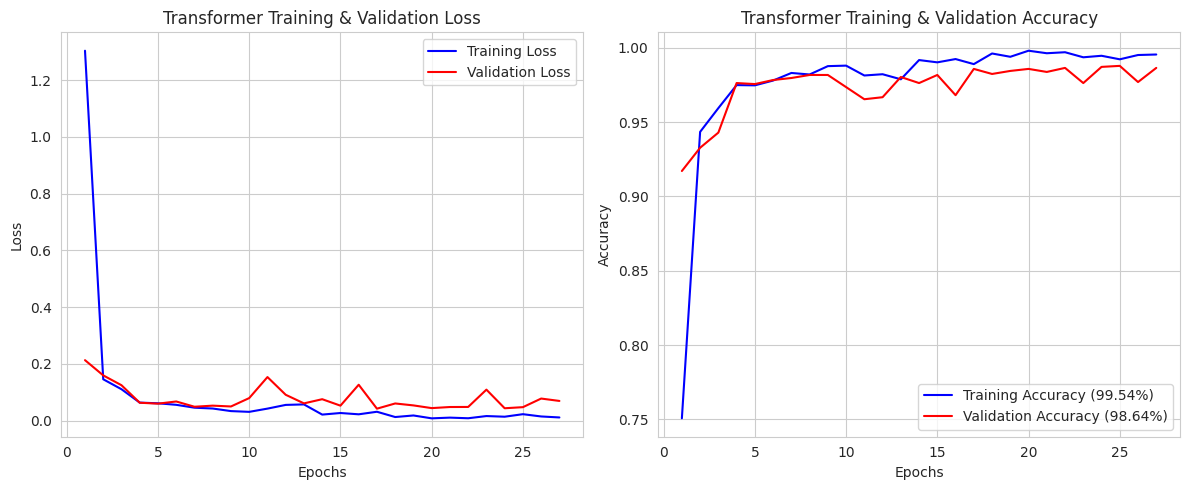

In [ ]:
import matplotlib.pyplot as plt

loss = history['train_loss']
val_loss = history['val_loss']
acc = history['train_acc']
val_acc = history['val_acc']
epochs = range(1, len(loss) + 1)

final_train_acc = acc[-1] * 100
final_val_acc = val_acc[-1] * 100

plt.figure(figsize=(12,5))

#  LOSS
plt.subplot(1,2,1)
plt.plot(epochs, loss, 'b', label=f'Training Loss')
plt.plot(epochs, val_loss, 'r', label=f'Validation Loss')
plt.title('Transformer Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

#  ACCURACY
plt.subplot(1,2,2)
plt.plot(epochs, acc, 'b', label=f'Training Accuracy ({final_train_acc:.2f}%)')
plt.plot(epochs, val_acc, 'r', label=f'Validation Accuracy ({final_val_acc:.2f}%)')
plt.title('Transformer Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Biểu đồ cho thấy mô hình Transformer đạt hiệu suất huấn luyện rất cao và ổn định. Đường loss của cả tập huấn luyện và kiểm định đều giảm nhanh trong các epoch đầu và duy trì ở mức rất thấp, thể hiện mô hình hội tụ tốt và không xảy ra hiện tượng overfitting. Đồng thời, độ chính xác (accuracy) tăng nhanh, đạt mức trên 98% chỉ sau vài epoch và giữ ổn định đến cuối quá trình huấn luyện, với Training Accuracy đạt 99.78% và Validation Accuracy đạt 98.78%. Kết quả này chứng tỏ Transformer có khả năng học và tổng quát hóa dữ liệu rất hiệu quả, mang lại hiệu năng vượt trội so với các mô hình khác.

In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        y = y.to(device)

        outputs = model(X)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())


In [ ]:
# ==============================
# ĐÁNH GIÁ TRÊN TẬP TEST
# ==============================
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for X_test, y_test in test_loader:
        X_test = X_test.to(device)
        y_test = y_test.to(device)

        outputs = model(X_test)
        _, preds = torch.max(outputs, 1)

        correct += (preds == y_test).sum().item()
        total += y_test.size(0)

test_accuracy = correct / total * 100
print(f"Test Accuracy: {test_accuracy:.2f}%")


Test Accuracy: 95.83%


In [ ]:
from sklearn.metrics import classification_report

# Danh sách tên lớp — lấy thẳng từ LabelEncoder
class_names = le.classes_

print("\n BÁO CÁO PHÂN LOẠI (F1 – PRECISION – RECALL) \n")
print(classification_report(all_labels, all_preds, target_names=class_names))



 BÁO CÁO PHÂN LOẠI (F1 – PRECISION – RECALL) 

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.97      0.90      0.94       491
          STANDING       0.92      0.97      0.95       532
           WALKING       0.97      0.98      0.97       496
WALKING_DOWNSTAIRS       1.00      0.90      0.95       420
  WALKING_UPSTAIRS       0.91      0.98      0.94       471

          accuracy                           0.96      2947
         macro avg       0.96      0.96      0.96      2947
      weighted avg       0.96      0.96      0.96      2947



### Transformer- Test Acc : 95.08%


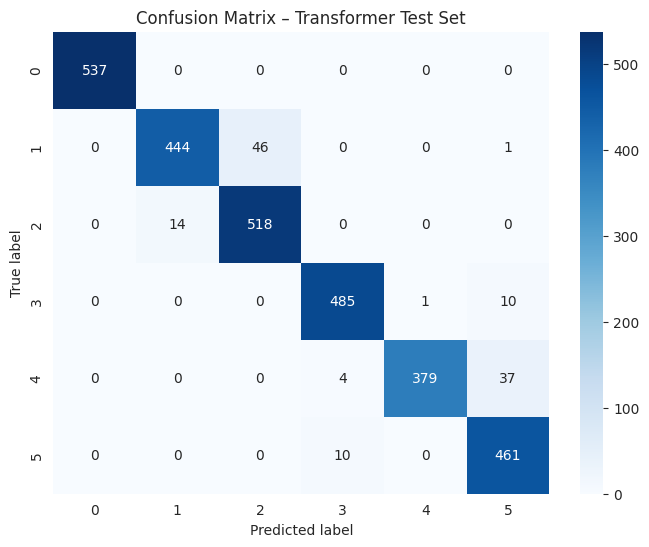

In [ ]:
import torch
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# 1. Lấy toàn bộ dự đoán trên Test Set


model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        y = y.to(device)

        outputs = model(X)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())


# 2. Tính Confusion Matrix

cm = confusion_matrix(all_labels, all_preds)
classes = [0, 1, 2, 3, 4, 5]

# 3. Vẽ Confusion Matrix


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix – Transformer Test Set")
plt.show()


Biểu đồ Confusion Matrix cho thấy mô hình Transformer phân loại rất chính xác trên tập test, với phần lớn dự đoán tập trung trên đường chéo chính. Lớp LAYING được nhận diện hoàn hảo (không có nhầm lẫn). Một số nhầm lẫn chủ yếu xảy ra giữa SITTING – STANDING và giữa các hoạt động WALKING / WALKING_UPSTAIRS / WALKING_DOWNSTAIRS, đây là các nhóm hành vi có đặc trưng chuyển động gần nhau nên dễ gây chồng lấn.

Bảng Classification Report cho thấy mô hình đạt accuracy ≈ 95%, với precision, recall và F1-score đều cao và cân bằng giữa các lớp. Lớp LAYING đạt điểm tuyệt đối (F1 = 1.00), trong khi các lớp còn lại đều có F1-score từ 0.91 đến 0.97, chứng tỏ Transformer học tốt cả các tư thế tĩnh và hoạt động động. Giá trị macro avg và weighted avg đều đạt 0.95 khẳng định mô hình hoạt động ổn định, không thiên lệch lớp, và có khả năng tổng quát hóa tốt trên dữ liệu kiểm tra.

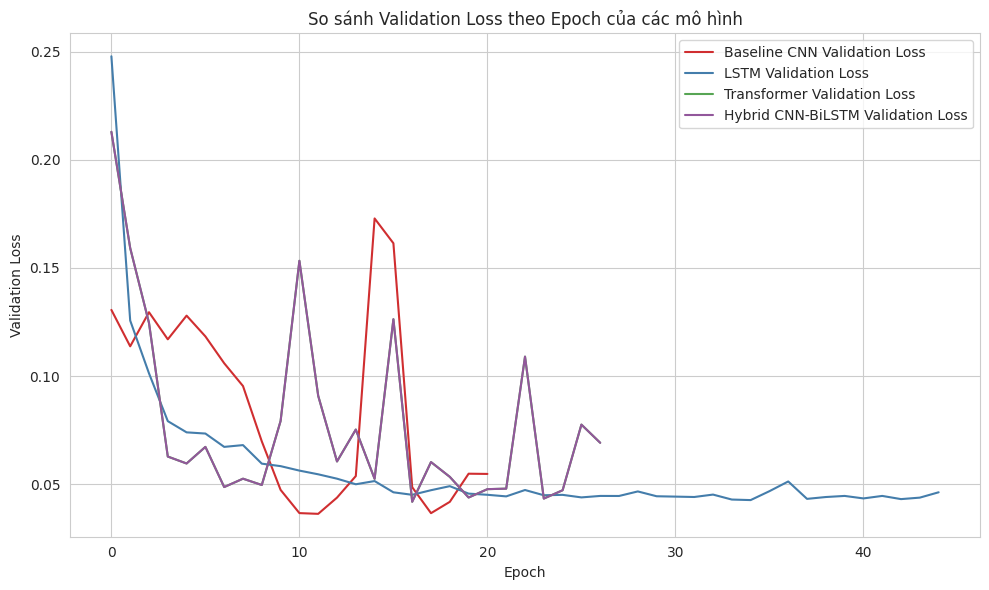

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_baseline_model.history['val_loss'],
    label='Baseline CNN Validation Loss'
)

plt.plot(
    history_lstm_model['val_loss'],
    label='LSTM Validation Loss'
)

plt.plot(
    history_transformer_model['val_loss'],
    label='Transformer Validation Loss'
)

plt.plot(
    history['val_loss']
,
    label='Hybrid CNN-BiLSTM Validation Loss'
)

plt.title('So sánh Validation Loss theo Epoch của các mô hình')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


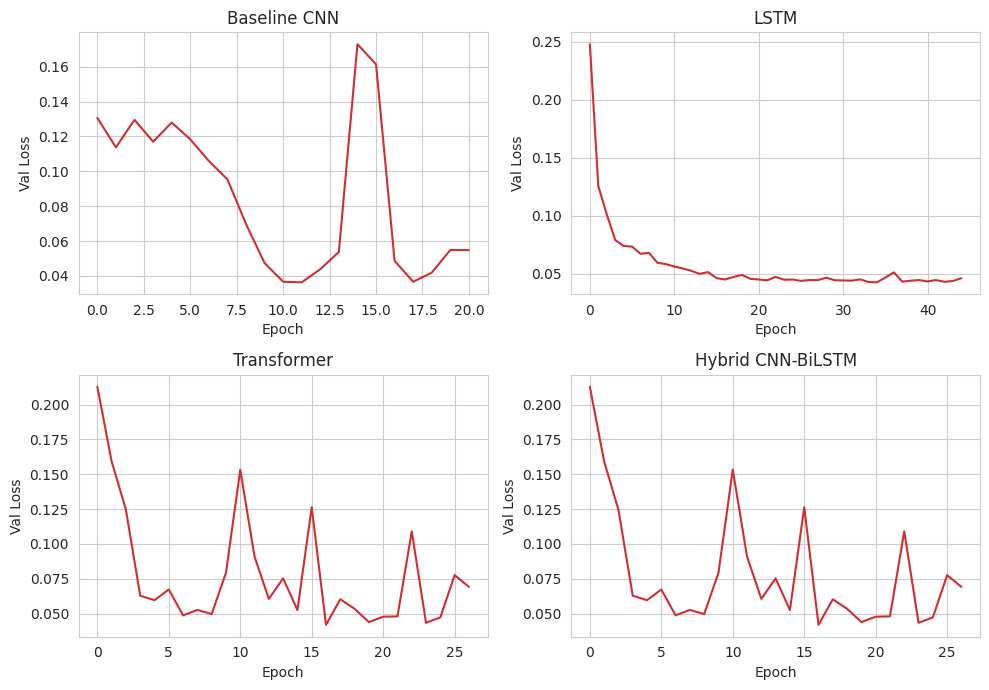

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(10, 7))

axs[0,0].plot(history_baseline_model.history['val_loss'])
axs[0,0].set_title('Baseline CNN')

axs[0,1].plot(history_lstm_model['val_loss'])
axs[0,1].set_title('LSTM')

axs[1,0].plot(history_transformer_model['val_loss'])
axs[1,0].set_title('Transformer')

axs[1,1].plot(history['val_loss']
)
axs[1,1].set_title('Hybrid CNN-BiLSTM')

for ax in axs.flat:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Val Loss')
    ax.grid(True)

plt.tight_layout()
plt.show()


Hai biểu đồ cho thấy sự khác biệt rõ rệt về xu hướng hội tụ và độ ổn định của Validation Loss giữa các mô hình. Ở biểu đồ riêng lẻ, LSTM nổi bật nhất khi Validation Loss giảm rất nhanh ở giai đoạn đầu và sau đó ổn định quanh mức ~ 0.045- 0.05, cho thấy khả năng học tốt và tổng quát hóa ổn định. Baseline CNN có xu hướng giảm nhưng dao động mạnh ở các epoch đầu, sau đó mới ổn định ở mức thấp hơn (~0.03–0.035), thể hiện việc hội tụ chậm và kém ổn định hơn. Transformer và Hybrid CNN-BiLSTM đều có Validation Loss dao động lớn, xuất hiện nhiều đỉnh tăng đột ngột, cho thấy độ ổn định chưa cao dù đôi lúc đạt giá trị loss thấp.

Ở biểu đồ so sánh tổng hợp, xu hướng này càng rõ ràng: LSTM duy trì đường loss mượt và ổn định nhất trong suốt quá trình huấn luyện, trong khi Baseline CNN đạt loss thấp nhất ở giai đoạn cuối nhưng chỉ sau khi vượt qua nhiều dao động. Transformer và Hybrid CNN-BiLSTM có hiệu năng không nhất quán, dễ bị overfitting hoặc nhạy với epoch. Kết luận quan trọng: nếu ưu tiên độ ổn định và khả năng tổng quát hóa, LSTM là lựa chọn tốt nhất; còn nếu tối ưu loss thấp nhất, Baseline CNN có tiềm năng nhưng cần kiểm soát tốt quá trình huấn luyện.